In [34]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
!pip install catboost
import catboost
import shap

In [35]:
# Загрузка данных
path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/bank-customer-churn-prediction


In [36]:
data = pd.read_csv('/kaggle/input/bank-customer-churn-prediction/Churn_Modelling.csv')

# Посмотрим на первые 5 строчек датасета
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [37]:
# Посмотрим, есть ли в датасете пустые значения
data.info()
# Nan-объектов нет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [38]:
# Удалим лишние колонки
data = data.drop(columns=['RowNumber','CustomerId','Surname'])

In [39]:
# Списки с именми колонок с численными и категориальными признаками
num_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

cat_cols = [
    'Geography',
    'Gender'
]

feature_cols = num_cols + cat_cols
target_col = 'Exited'

In [40]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


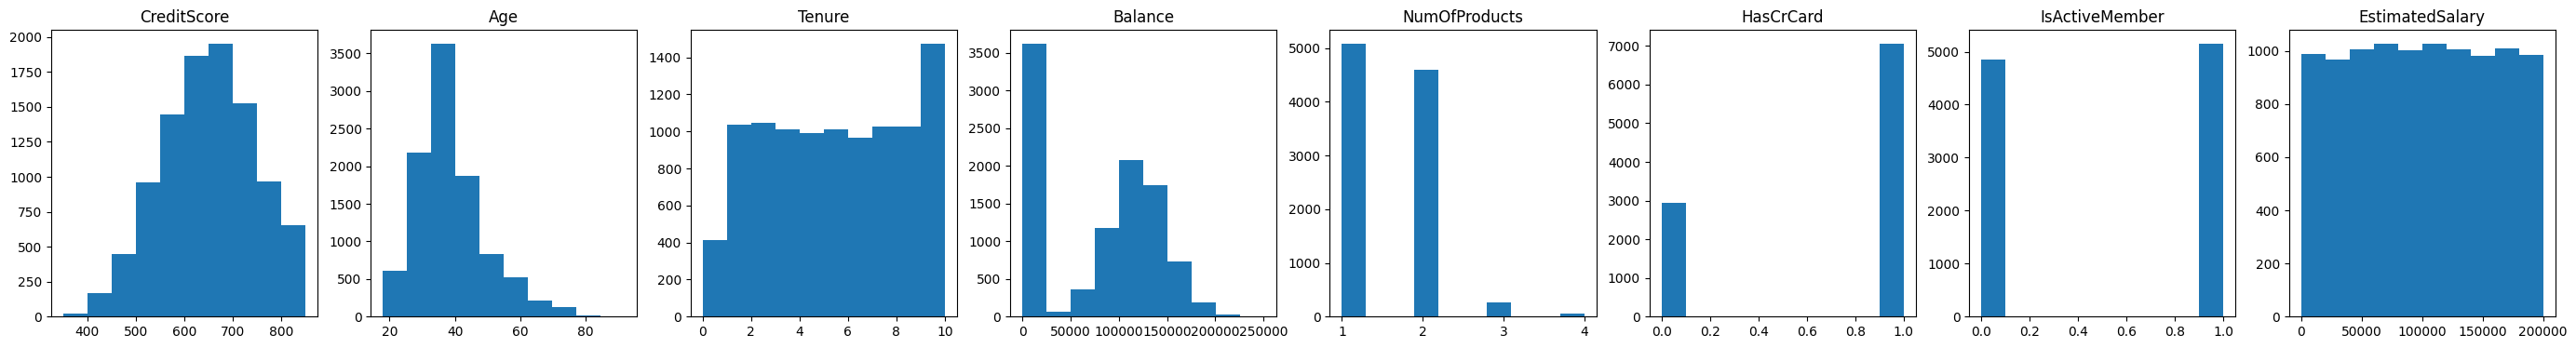

In [41]:
# Гистограммы для численных признаков
plt.figure(figsize=(48, 4))
[ ( plt.subplot(1, 11, i+1), plt.hist(data[cols]),plt.title(f'{cols}')) for i,cols in enumerate(num_cols)]
verbose = False

In [42]:
# Количество каждого значения для категориальных признаков
[data[col].value_counts() for col in cat_cols]

[Geography
 France     5014
 Germany    2509
 Spain      2477
 Name: count, dtype: int64,
 Gender
 Male      5457
 Female    4543
 Name: count, dtype: int64]

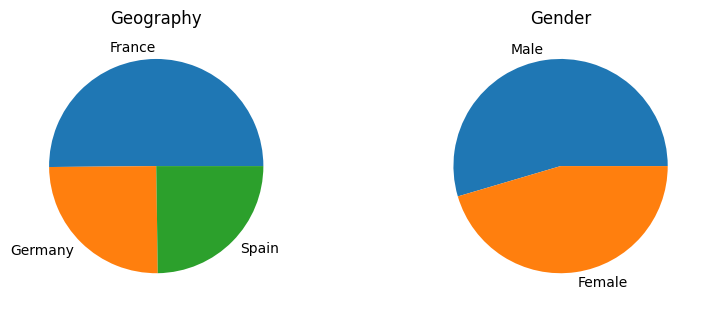

In [43]:
plt.figure(figsize=(20, 16))
[ ( plt.subplot(4, 4, i+1),  plt.pie(data[cols].value_counts(),labels=data[cols].value_counts().index)  ,plt.title(f'{cols}')) for i,cols in enumerate(cat_cols)]
verbose=False

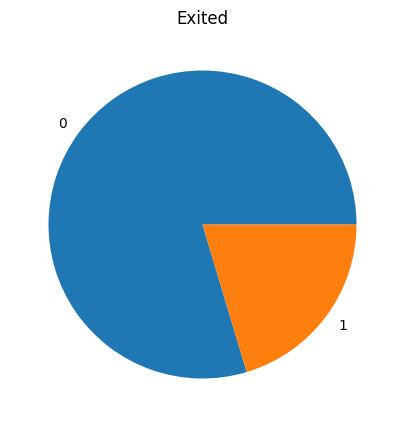

In [44]:
# Классы несбалансированны - в качестве метрики используем roc_auc
plt.figure(figsize=(5, 5))
plt.pie(data[target_col].value_counts(),labels=data[target_col].value_counts().index)
plt.title(target_col)
verbose = False

In [45]:
data[target_col].value_counts()

,count
Exited,
0,7963
1,2037


Обработка данных,чтобы к ним можно было применить LogisticRegression.

Отнормируем числовые признаки с помощью StandardScaler, категориальные закодируем с помощью one-hot-encoding'а.

In [46]:
scaler = StandardScaler()
data_num_cols = scaler.fit_transform(data[num_cols])
data_num = pd.DataFrame(data_num_cols, columns=num_cols)

encoder = OneHotEncoder()
encoded_cat = encoder.fit_transform(data[cat_cols])
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
data_cat = pd.DataFrame(encoded_cat.toarray(), columns=encoded_cat_names)

data_scaled = pd.concat([data_num, data_cat], axis=1)
data_scaled.head(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.326221,0.293517,-1.04176,-1.225848,-0.911583,0.646092,0.970243,0.021886,1.0,0.0,0.0,1.0,0.0


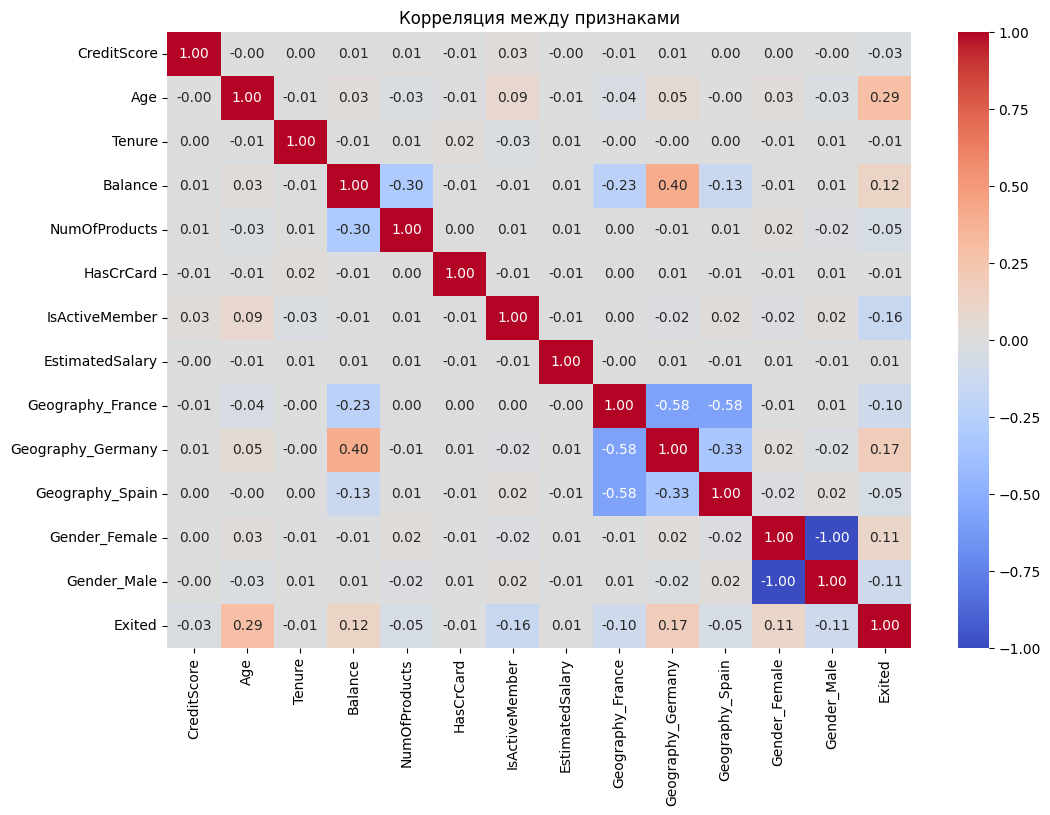

In [47]:
# Считаем матрицу корреляций по числовым признакам
data_corr = pd.concat([data_scaled, data[target_col]], axis=1)
corr_matrix = data_corr.corr()

# print(corr_matrix['Exited'].sort_values(ascending=False))
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция между признаками')
plt.show()

## Применение линейных моделей

In [48]:
model = LogisticRegression(random_state=42)
params = [{
    'penalty': ['l1','l2'],
    'class_weight': ['balanced', None],
    'solver': ['liblinear','saga'],
    'C': [100, 10, 1, 0.1, 0.01, 0.001]
}]
grid_search = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, data[target_col], test_size=0.2, random_state=42)


grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid=[{'C': [100, 10, 1, 0.1, 0.01, 0.001],
                          'class_weight': ['balanced', None],
                          'penalty': ['l1', 'l2'],
                          'solver': ['liblinear', 'saga']}],
             scoring='roc_auc')

In [49]:
y_pred = grid_search.predict(X_test)

roc_auc_score(y_test, y_pred)

np.float64(0.7190773191713735)

In [50]:
best_model = grid_search.best_estimator_

feature_importance = best_model.coef_[0]


feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values('Abs_Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance  Abs_Importance
1                 Age    0.798866        0.798866
9   Geography_Germany    0.539929        0.539929
12        Gender_Male   -0.536910        0.536910
6      IsActiveMember   -0.449441        0.449441
8    Geography_France   -0.195941        0.195941
3             Balance    0.171720        0.171720
10    Geography_Spain   -0.072539        0.072539
0         CreditScore   -0.063404        0.063404
4       NumOfProducts   -0.048650        0.048650
2              Tenure   -0.031899        0.031899
7     EstimatedSalary    0.010648        0.010648
5           HasCrCard   -0.009203        0.009203
11      Gender_Female    0.000000        0.000000


Ключевые признаки для логистической регрессии:

1.   Age - с увеличением возраста вероятность оттока возрастает
2.   Geography_Germany - клиенты из Германии наиболее склонны к оттоку в сравнение с клиентами из Франции и Испании
3.   Gender_Male и IsActiveMember - мужчины и активные пользователи менее склонны отказываться от услуг




На первом этапе была обучена модель логистической регрессии, поскольку она проста в интерпретации и позволяет быстро оценить влияние отдельных признаков на целевую переменную.
Для построения более точной модели воспользуемся градиентным бустингом (CatBoostClassifier).

## Градиентный бустинг

In [51]:
X_train, X_test, y_train, y_test = train_test_split(data[feature_cols], data[target_col], test_size=0.2)

model = catboost.CatBoostClassifier(random_state = 42, cat_features=cat_cols)
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

Learning rate set to 0.052963
0:	learn: 0.6481233	test: 0.6486290	best: 0.6486290 (0)	total: 17.8ms	remaining: 17.8s
1:	learn: 0.6110552	test: 0.6125121	best: 0.6125121 (1)	total: 30.3ms	remaining: 15.1s
2:	learn: 0.5774246	test: 0.5793323	best: 0.5793323 (2)	total: 40ms	remaining: 13.3s
3:	learn: 0.5474605	test: 0.5501397	best: 0.5501397 (3)	total: 48.8ms	remaining: 12.1s
4:	learn: 0.5235893	test: 0.5271405	best: 0.5271405 (4)	total: 58.3ms	remaining: 11.6s
5:	learn: 0.5045615	test: 0.5087891	best: 0.5087891 (5)	total: 70.2ms	remaining: 11.6s
6:	learn: 0.4839607	test: 0.4894086	best: 0.4894086 (6)	total: 79.1ms	remaining: 11.2s
7:	learn: 0.4682346	test: 0.4741445	best: 0.4741445 (7)	total: 88.1ms	remaining: 10.9s
8:	learn: 0.4534236	test: 0.4597815	best: 0.4597815 (8)	total: 97.3ms	remaining: 10.7s
9:	learn: 0.4430778	test: 0.4502680	best: 0.4502680 (9)	total: 106ms	remaining: 10.5s
10:	learn: 0.4307897	test: 0.4391006	best: 0.4391006 (10)	total: 115ms	remaining: 10.4s
11:	learn: 0.42

In [52]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

np.float64(0.8644526736779736)

Для интерпретации модели CatBoost использован метод SHAP

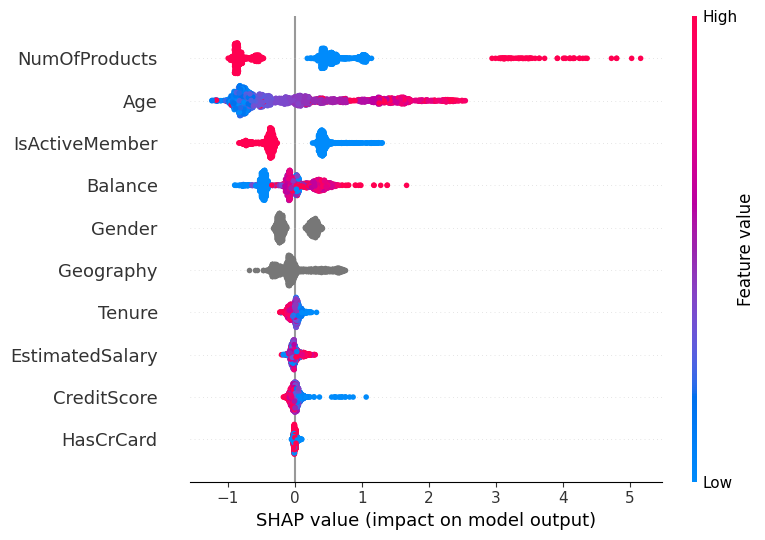

In [53]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Наиболее важные признаки по SHAP:

1.   Age - с увеличением возраста вероятность оттока возрастает
2.   NumOfProducts - клиенты, пользующиеся большим количеством продуктов банка с большой вероятностью остаются, в отличие от клиентов с небольшим количеством продуктов (хотя имеются выбросы - есть группа клиентов с большим NumOfProducts, которая склонна к оттоку)
3.   IsActiveMember - неактивные клиенты чаще уходят
4.   Balance - клиенты с большим балансом склонны к оттоку

Можно заметить, что влияние признака Gender незначительно для модели. Признак Geography влияет на целевую переменную (как и в модели LogisticRegression)